# Improving Computer Vision Accuracy using Convolutions

지금까지 Deep Neural Network (DNN) 를 이용해서 패션 mnist 를 분류했다.  

In [60]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten

In [61]:
import tensorflow as tf
# TensorFlow가 GPU 메모리를 처음부터 크게 선점하지 않고, 필요한 만큼 점진적으로 사용하도록 설정
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [62]:
mnist = tf.keras.datasets.fashion_mnist

In [63]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [64]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [65]:
X_train.shape

(60000, 28, 28)

In [66]:
X_test.shape

(10000, 28, 28)

In [67]:
# 이미지 처리에서는 이미지를 그대로 사용함.

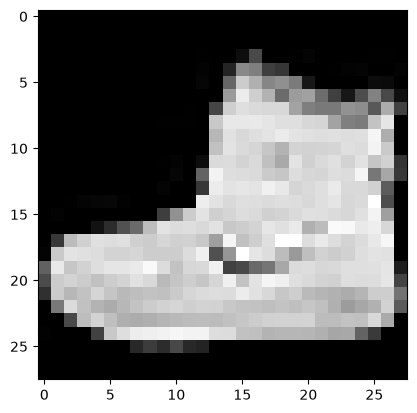

In [68]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap='gray')
plt.show()

- image 데이터 표현

In [69]:
# gray scale
60000, 28, 28, 1

(60000, 28, 28, 1)

DNN에서는 정확도가, 트레이닝셋은 89% 정도이고 테스트셋으로는  87% 정도가 나왔다. 

이제 Convolutional Neural Networks 이용해서 정확도를 향상시켜본다.




In [70]:
from keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten
from tensorflow import keras

In [71]:
def build_model(input_shape):  # (28, 28, 1)
    model = Sequential()
    model.add(keras.Input(shape = input_shape))
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation=keras.activations.relu ))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    model.add(Conv2D(filters=32, kernel_size=(3,3), activation=keras.activations.relu))
    model.add(MaxPool2D(pool_size=(2,2), strides=2))
    # 여기까지는 이미지의 특징 파악, 이후 분류를 위해 ANN 실행
    model.add(Flatten())
    model.add(Dense(128, keras.activations.relu))
    model.add(Dense(10, keras.activations.softmax))

    # model compile
    model.compile(optimizer=keras.optimizers.Adam(), 
                  loss= keras.losses.SparseCategoricalCrossentropy(),
                  metrics=[keras.metrics.SparseCategoricalAccuracy()])
    return model
    


In [72]:
model = build_model((28,28,1))

In [73]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,922 (480.16 KB)

 Trainable params: 122,922 (480.16 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# 오류 발생
# InternalError: Graph execution error:
# ...

#   File "/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py", line 125, in wrapper

# Autotuning failed for HLO: %cudnn-conv-bias-activation.6 = (f32[4,64,26,26]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.17, %transpose, %arg3.1), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/conv2d_2_1/convolution" source_file="/mnt/e/gg_ai_merbership_1th/dnn_cnn_ex/.venv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1221}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} with error: NOT_FOUND: No valid config found!
# 	 [[{{node StatefulPartitionedCall}}]] [Op:__inference_multi_step_on_iterator_1703]

In [75]:
#  NVIDIA GeForce GTX 1050 2G VRAM
# UDA/cuDNN 조합에서 GTX 1050의 Conv2D/cuDNN 실행 호환성 문제
# VRAM 부족보다는 TensorFlow 2.21.0 + 현재 CUDA/cuDNN 조합의 GPU convolution 호환 문제로 보는 것이 더 타당
# 즉, cuDNN이 Conv2D 연산에 사용할 수 있는 유효한 커널 구성을 찾지 못한 것이다. 
# 현재 TensorFlow 2.21.0 공식 빌드는 CUDA 12.5, cuDNN 9.3 기준인데, 
# 현재 uv 환경에는 CUDA 12.9 계열과 cuDNN 9.25가 설치되어 있다. 공식 빌드 조합과 차이가 있다.

# 확인방법
# uv pip show nvidia-cuda-runtime-cu12
# uv pip show nvidia-cudnn-cu12
# uv pip show tensorfow

# rm -rf .venv
# uv init --bare
# uv add "tensorflow[and-cuda]==2.20.0"  <-- 이것도 오류
# uv add "tensorflow[and-cuda]==2.17.1"  <-- 여기서 학습이 됨

# README.md 파일 참고해서 가상환경 셋팅하기

# uv run python -c "import tensorflow as tf; print(tf.__version__); print(tf.config.list_physical_devices('GPU'))"


In [76]:
history = model.fit(
  X_train, y_train, 
  epochs=20, 
  batch_size=8,
  # validation_data=(X_test, y_test)
  validation_split=0.2
  )

Epoch 1/20
  51/6000 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.7765 - sparse_categorical_accuracy: 0.4069

2026-08-31 05:44:49.923533: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion', 4 bytes spill stores, 12 bytes spill loads



6000/6000 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.4357 - sparse_categorical_accuracy: 0.8396 - val_loss: 0.3305 - val_sparse_categorical_accuracy: 0.8811
Epoch 2/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.2946 - sparse_categorical_accuracy: 0.8908 - val_loss: 0.2888 - val_sparse_categorical_accuracy: 0.8950
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.2511 - sparse_categorical_accuracy: 0.9063 - val_loss: 0.2565 - val_sparse_categorical_accuracy: 0.9075
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.2238 - sparse_categorical_accuracy: 0.9151 - val_loss: 0.2829 - val_sparse_categorical_accuracy: 0.9019
Epoch 5/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.1987 - sparse_categorical_accuracy: 0.9252 - val_loss: 0.2682 - val_sparse_categorical_accuracy: 0.9042
Epoch 6/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.1780 - sparse_categorical_accuracy: 0.9332 - val_loss: 0.2846 - val_sparse_categorical_accuracy: 0.90

In [77]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6242 - sparse_categorical_accuracy: 0.8969


[0.6241955757141113, 0.8968999981880188]

## 학습결과 확인

In [78]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy'])

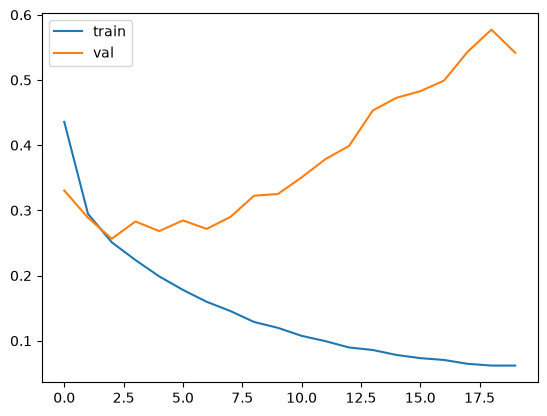

In [79]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()


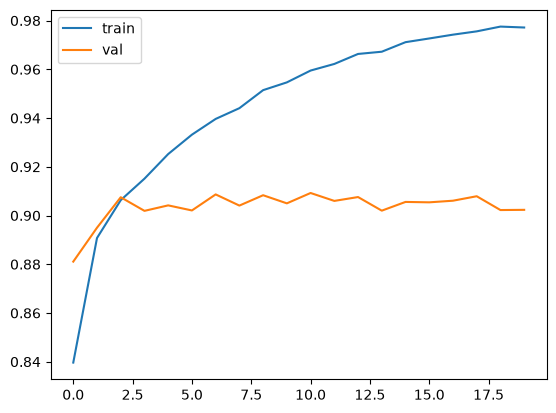

In [80]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.legend(['train', 'val'])
plt.show()

## 모델 평가

In [81]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [82]:
y_pred_pro = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [83]:
y_pred_pro

array([[1.1460806e-24, 3.5244530e-27, 5.9597698e-27, ..., 2.7245662e-20,
        3.4436085e-28, 1.0000000e+00],
       [7.5974519e-15, 2.7843800e-42, 1.0000000e+00, ..., 1.8082732e-31,
        3.2095299e-26, 3.5172125e-35],
       [2.7875815e-20, 1.0000000e+00, 6.4883424e-29, ..., 1.6672092e-36,
        1.6801025e-25, 7.4993472e-23],
       ...,
       [1.7610818e-40, 0.0000000e+00, 1.8269583e-39, ..., 0.0000000e+00,
        1.0000000e+00, 0.0000000e+00],
       [7.3559450e-25, 1.0000000e+00, 2.1335594e-26, ..., 4.4531920e-39,
        5.8615438e-31, 2.9352675e-28],
       [2.1332654e-11, 1.0053438e-17, 2.1092350e-09, ..., 2.4816968e-02,
        1.0854824e-05, 3.8885386e-08]], dtype=float32)

In [84]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.8969

In [85]:
# Fashion MNIST 클래스 이름
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
         'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 예측 label 이름으로 변환
predicted_labels = [class_names[i] for i in y_pred_labels]

In [86]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [87]:
import pandas as pd
df = pd.DataFrame(data=cm, columns=class_names)
df.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,791,1,17,14,3,1,159,0,14,0
1,1,979,1,10,5,0,2,0,2,0
2,17,0,849,6,39,1,87,0,1,0
3,11,2,14,883,42,0,42,2,2,2
4,0,0,84,13,805,0,94,0,4,0


<Axes: >

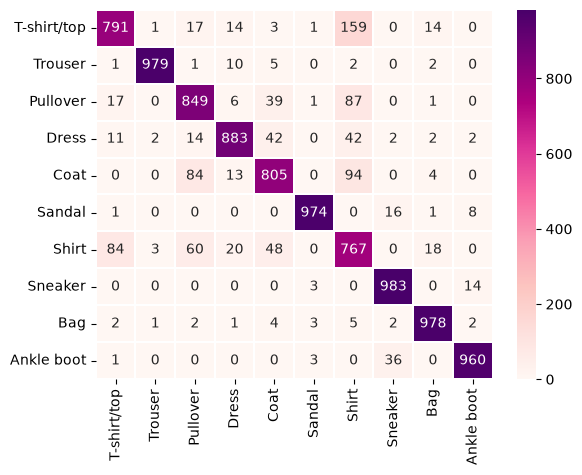

In [88]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df.columns,
          yticklabels=df.columns)

## EarlyStopping으로 다시 학습

In [89]:
from tensorflow.keras.callbacks import EarlyStopping

In [90]:
# 새로운 초기 가중치로 처음부터 다시 학습
# del model
tf.keras.backend.clear_session()

model = build_model((28,28,1))

In [91]:
# callback, 함수
# EarlyStopping(monitor='val_loss', mode=validation 로스 최소, patience=loss 올라가는것을 몇번 참느냐?, 
#  restore_best_weights=True weight가 가장 좋았던 상태로 되돌리기 )
early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

In [92]:
# patience=5의 의미
# Epoch 10 : val_loss = 0.30  ← 최고 성능
# Epoch 11 : 개선 없음        ← 1
# Epoch 12 : 개선 없음        ← 2
# Epoch 13 : 개선 없음        ← 3
# Epoch 14 : 개선 없음        ← 4
# Epoch 15 : 개선 없음        ← 5 → 중단

In [93]:
# 학습
history2 = model.fit(
  X_train, y_train, 
  epochs = 100, 
  validation_split=0.2, 
  callbacks=[early_stopping])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4828 - sparse_categorical_accuracy: 0.8257 - val_loss: 0.3749 - val_sparse_categorical_accuracy: 0.8580
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.3192 - sparse_categorical_accuracy: 0.8816 - val_loss: 0.3132 - val_sparse_categorical_accuracy: 0.8834
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2766 - sparse_categorical_accuracy: 0.8983 - val_loss: 0.2795 - val_sparse_categorical_accuracy: 0.8952
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2454 - sparse_categorical_accuracy: 0.9085 - val_loss: 0.2729 - val_sparse_categorical_accuracy: 0.8997
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2209 - sparse_categorical_accuracy: 0.9172 - val_loss: 0.2680 - val_sparse_categorical_accuracy: 0.9034
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2032 - sparse_categorical_accuracy: 0.9226 - val_loss: 0.2571 - val_sparse_categorical_ac

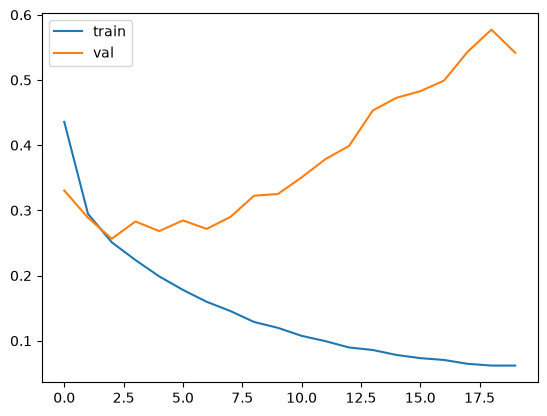

In [98]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.show()

In [99]:
# 가장 높은 확률을 가진 클래스 인덱스를 예측 label로 계산
y_pred_labels = y_pred_pro.argmax(axis=1)

accuracy_score(y_test, y_pred_labels)

0.8969

In [100]:
cm = confusion_matrix(y_test, y_pred_pro.argmax(axis=1))

In [103]:
import pandas as pd
df2 = pd.DataFrame(data=cm, columns=class_names)
df2.head()

,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
0,791,1,17,14,3,1,159,0,14,0
1,1,979,1,10,5,0,2,0,2,0
2,17,0,849,6,39,1,87,0,1,0
3,11,2,14,883,42,0,42,2,2,2
4,0,0,84,13,805,0,94,0,4,0


<Axes: >

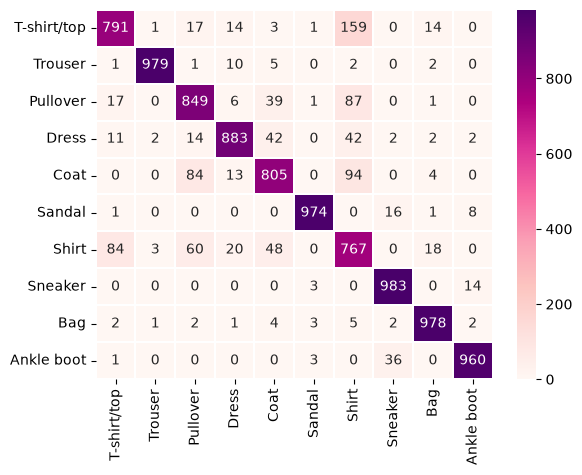

In [104]:
import seaborn as sb
sb.heatmap(df, 
          annot=True, 
          fmt='d', 
          linewidths=0.1, 
          cmap='RdPu',
          xticklabels=df2.columns,
          yticklabels=df2.columns)

트레이닝셋은 97% , 테스트셋은 89% 까지 나온다.


에포크를 20까지 해보면, 트레이닝셋 정확도는 올라가지만 밸리데이션 정확도는 내려간다. 즉, 오버핏팅이 된다.







```
import tensorflow as tf
mnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
training_images=training_images.reshape(60000, 28, 28, 1)
training_images=training_images / 255.0
test_images = test_images.reshape(10000, 28, 28, 1)
test_images=test_images/255.0
```
